In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import xarray as xr
import cartopy.crs as ccrs

In [2]:
#open dataset
ds = xr.open_dataset('/Users/gabrielagarcia/Desktop/Fall 2026/Geol 415/hw4/GEOS-CF_AirQuality_20180101_0030z.nc4', engine='netcdf4')


In [3]:
#import dask
#print(dask.__version__)

In [4]:
#install conda-forge dask Trouble
#%conda install -c conda-forge dask

In [5]:
#import dask
#import xarray as xr

#print(dask.__version__)
#print(xr.__version__)

In [6]:
#%conda install -c conda-forge --force-reinstall dask

In [7]:
#import dask
#print(dask.__version__)

In [8]:
#import sys
#import dask

#print("Python:", sys.executable)
#print("Dask location:", dask.__file__)
#print("Dask version:", dask.__version__)

In [9]:
#%pip show dask

In [10]:
#%pip uninstall -y dask

In [11]:
#%pip install --no-cache-dir dask==2025.11.0

In [12]:
#import dask
#print(dask.__version__)
#print(dask.__file__)

In [13]:
#import xarray as xr

In [14]:
ds

<xarray.Dataset> Size: 21MB
Dimensions:        (time: 1, lev: 1, lat: 721, lon: 1440)
Coordinates:
  * time           (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev            (lev) float64 8B 72.0
  * lat            (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon            (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    CO             (time, lev, lat, lon) float32 4MB ...
    NO2            (time, lev, lat, lon) float32 4MB ...
    O3             (time, lev, lat, lon) float32 4MB ...
    PM25_RH35_GCC  (time, lev, lat, lon) float32 4MB ...
    SO2            (time, lev, lat, lon) float32 4MB ...
Attributes: (12/28)
    Contact:               http://gmao.gsfc.nasa.gov
    History:               Original file generated: Mon Dec 24 13:37:28 2018 GMT
    Source:                cak_Icarus-1_0_GCCv12-00-01_v1_010 experiment_id: ...
    Conventions:           CF-1
    Title:                 GEOS CF (Composition Forecast)
    Institution:           NASA Global Modeling and Assimilation Office
    ...                    ...
    DataResolution:        0.25 x 0.25
    LongName:              GEOS CF 2d time-averaged air quality concentration...
    ShortName:             CF01Raqc_1hrT_g1440x721_V1
    Comment:               GMAO filename: c360_GEOS-CF.chm_tavg_1hr_g1440x721...
    Filename:              GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...
    GranuleID:             GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...

In [15]:
#assign variable name to NO2 dataset
O3= ds.O3
#convert O3 to ppm
O3 = ds.O3 * 1e6

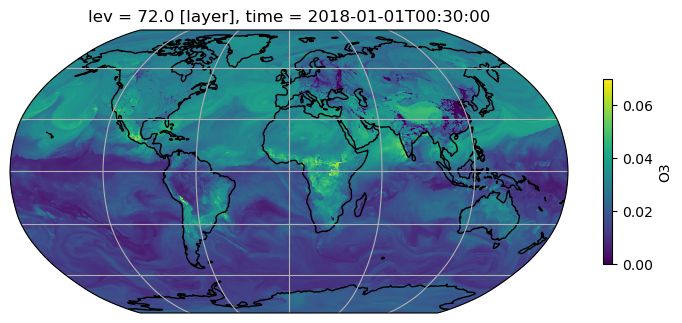

In [16]:
#plot figure
#coordinate reference system (map projection)
fig = plt.figure(figsize=(9,6))
ax = plt.axes(projection=ccrs.Robinson())
O3.plot(ax=ax, transform=ccrs.PlateCarree(), 
        cbar_kwargs={'shrink': 0.4}) # make axis smaller
ax.coastlines()
ax.gridlines()

In [17]:
#find maximum O3 value
max_O3 =ds.O3.max() 
max_O3ppm = max_O3* 1e6
print(max_O3ppm)

<xarray.DataArray 'O3' ()> Size: 8B
array(0.06973278)


In [18]:
#find maximum latitude and longitude of max O3
max_point = ds.O3.where(ds.O3 == max_O3, drop=True)

lat = max_point.lat.values
lon = max_point.lon.values

In [19]:
print("Latitude:", lat)
print("Longitude:", lon)

Latitude: [34.5]
Longitude: [-118.75]


In [23]:
#find location where O3 is minimum
min_index = ds.O3.values.argmin()

# Convert flattened index to indices for each dimension
time_idx, lev_idx, lat_idx, lon_idx = np.unravel_index(
    min_index, ds.O3.shape
)

# convert to coordinate values
time_min = ds.time.values[time_idx]
lev_min = ds.lev.values[lev_idx]
lat_min = ds.lat.values[lat_idx]
lon_min = ds.lon.values[lon_idx]

# Get minimum O3
min_O3 = ds.O3.values.flatten()[min_index]

print("Minimum O3:", min_O3)
print("Latitude:", lat_min)
print("Longitude:", lon_min)

Minimum O3: 0.0
Latitude: 53.0
Longitude: 73.25


In [26]:
#find O3 around LA using latitude of 34.0522 and longitude of -118.2437
la_lat = 34.0522
la_lon = -118.2437
O3_LA = ds.O3.sel(lat= la_lat, lon= la_lon, method="nearest")

#print value converted to ppm
O3_LA_ppm = O3_LA.values*1e6
print(O3_LA_ppm)

[[0.04540198]]


In [27]:
#find O3 around Hawaii using latitude of 34.0522 and longitude of -118.2437
HI_lat = 19.54
HI_lon = 155.58
O3_HI = ds.O3.sel(lat= HI_lat, lon= HI_lon, method="nearest")

#print value converted to ppm
O3_HI_ppm = O3_HI.values*1e6
print(O3_HI_ppm)

[[0.0227883]]


In [20]:
#a.  Based off the map, O3 seems qualitativly bad on the southern part of Africa, southern parts of South America and southern parts of Mexico.
#b. The maximum O3 value is at latitude 34.5 and longitude -118.75.
#c. O3 seems qualitatively low in the Southern Hemisphere oceans.
#d. One of the locations where O3 is the lowest (0ppm) is at latitude 53.0 and longitude 73.25, which is North Kazakhstan.
#e. The O3 concentration around LA is 0.045 ppm.
#f. The O3 concentration over Hawaii at the latitude of 34.0522 and longitude -118.2437 is 0.023 ppm.